In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plot_scripts as plts
plt.style.use("mplstyle")

In [2]:
# def FGname(inp_signal):
#     if (inp_signal == '21cm'):
#         FG = 'None'
#         dataname = '21cm'
#     elif (inp_signal == 'FG+21cm'):
#         FG = 'Smooth'
#         dataname = 'FG'
#     elif (inp_signal == 'FG+MM+21cm'):
#         FG = 'Unsmooth'
#         dataname = 'FGMM'
#     return FG, dataname

inp_signal = 21cm, flag = NOFLAG, scf = None
inp_signal = 21cm, flag = NOFLAG, scf = None
Saved: plots/dctfft_Flag_NOFLAG.pdf


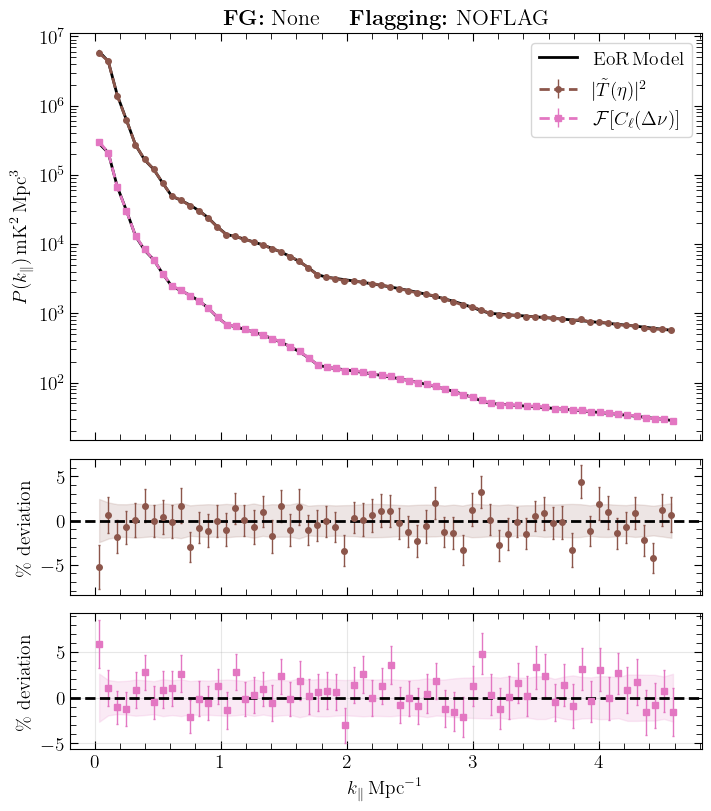

In [3]:
path = 'results'
mode = 'NOFLAG'
# mode = 'PERIODIC'
# mode = 'RANDOM'
# mode = 'PERIODIC+RANDOM'
inp_signal = '21cm' 
# inp_signal = 'FG+21cm'
# inp_signal = 'FG+MM+21cm'
SCF = 'None'
# SCF = 'Hann'

data = np.load(f"{path}/dct_inp_signal-{inp_signal}_flag-{mode}_SCF-{SCF}.npz")

kb_dct          = data["kb"]
mean_dct        = data["mean"]
err_dct         = data["err"]
binned_th_dct   = data["binned_th"]

inp_signal      = data["inp_signal"].tolist()
flag            = data["flag"].tolist()
scf             = data["SCF"].tolist()
print(f"inp_signal = {inp_signal}, flag = {flag}, scf = {scf}")

data = np.load(f"{path}/fft_inp_signal-{inp_signal}_flag-{mode}_SCF-{SCF}.npz")

kb_fft          = data["kb"]
mean_fft        = data["mean"]
err_fft         = data["err"]
binned_th_fft   = data["binned_th"]

inp_signal1      = data["inp_signal"].tolist()
flag1            = data["flag"].tolist()
scf1             = data["SCF"].tolist()
print(f"inp_signal = {inp_signal1}, flag = {flag1}, scf = {scf1}")





shift = 20.0  if (inp_signal == '21cm') else 1 # upward shift for clarity
offset_ratio = 0.0  # shift 2 percentage points in ratio plot (optional)
figname = f"plots/dctfft_Flag_{mode}.pdf"  
ylim=20 if (mode == 'NOFLAG') else 200
    
if (inp_signal == '21cm'):
    FG = 'None'
elif (inp_signal == 'FG+21cm'):
    FG = 'Smooth'
elif (inp_signal == 'FG+MM+21cm'):
    FG = 'Unsmooth'

fig, axes = plts.plot_compare_estimators(
    kb_fft, mean_fft * shift, err_fft*shift, binned_th_fft* shift,
    kb_dct, (mean_dct), err_dct, binned_th_dct,
    fft_label=r'$|\tilde{T}(\eta)|^2$',
    # fft_label=r'${\rm Delay\,spectrum\,squared}$',
    dct_label=r'${ \mathcal{F} [ C_\ell(\Delta\nu) ] }$',
    title = r"\rm{  {\bf FG:}~}" + fr"$\mathrm{{   {FG}   }} \quad$" + r"\rm{ {\bf Flagging:}~"+fr"$\rm{{ {mode} }} $",
    fft_dev_label=r'\rm{\% deviation}',
    dct_dev_label=r'\rm{\% deviation}',
    fft_color='C5', dct_color='C6',
    # title = r"$\bf{{Data:}}$",
    figname=figname,
    # ylim=ylim
)
